# Customer Churn Prediction

**PROVE IT — Day 03 — Build It**

A small, end-to-end classification project: load a customer dataset, clean it, train a model to predict churn, evaluate it, and explain what the results mean for the business.

**Dataset:** [Telecom Customer Churn Insights for Analysis](https://www.kaggle.com/datasets/abdullah0a/telecom-customer-churn-insights-for-analysis) — 1,000 telecom customers with account info and whether they churned.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 25)
RANDOM_STATE = 42

## 1. Load Data

In [2]:
df = pd.read_csv("../data/customer_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (1000, 10)


,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


## 2. Exploratory Data Analysis (EDA)

Data types and the balance of the target column, before touching anything.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   str    
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   str    
 6   InternetService  703 non-null    str    
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   str    
 9   Churn            1000 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 78.3 KB


Churn
Yes    883
No     117
Name: count, dtype: int64

Churn rate: 88.3%


/tmp/ipykernel_490/230915307.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette=["#4C72B0", "#DD8452"])


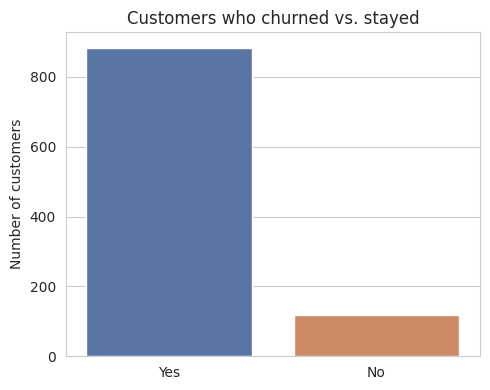

In [4]:
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print(f"\nChurn rate: {churn_counts['Yes'] / len(df):.1%}")

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn", palette=["#4C72B0", "#DD8452"])
plt.title("Customers who churned vs. stayed")
plt.xlabel("")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

**Note:** 88% of customers in this dataset churned — the opposite of a typical telecom dataset, where churn is usually the minority class (15-30%). Worth keeping in mind when reading the metrics below: a model that just predicted "Yes" for everyone would already score ~88% accuracy.

## 3. Cleaning (Missing Values, Duplicates, Outliers)

Three checks, run in order, each with the reasoning for the fix:

**3.1 Missing values.** `InternetService` is blank for 297 customers. Checking who they are first, rather than guessing:

In [5]:
missing_mask = df["InternetService"].isna()
print(f"Missing InternetService: {missing_mask.sum()}")
display(df.loc[missing_mask, ["ContractType", "TechSupport", "Churn"]].value_counts().head())

Missing InternetService: 297


ContractType    TechSupport  Churn
Month-to-Month  No           Yes      158
One-Year        No           Yes       90
Two-Year        No           Yes       49
Name: count, dtype: int64

Every single one of those 297 rows also has `TechSupport == "No"` — this isn't random missingness, it's customers who don't have an internet subscription at all, so the field was left blank instead of "DSL" or "Fiber Optic". That's a real category, not an error, so it's filled with the label `"No Internet"` rather than dropped or guessed.

In [6]:
df["InternetService"] = df["InternetService"].fillna("No Internet")
print("Remaining missing values:", df["InternetService"].isna().sum())

Remaining missing values: 0


**3.2 Duplicates.** Check for fully duplicated rows and repeated `CustomerID`s.

In [7]:
n_dupe_rows = df.duplicated().sum()
n_dupe_ids = df["CustomerID"].duplicated().sum()
print(f"Fully duplicated rows: {n_dupe_rows}")
print(f"Duplicate CustomerIDs: {n_dupe_ids}")

df = df.drop_duplicates().drop_duplicates(subset="CustomerID", keep="first")
print("Shape after de-duplication:", df.shape)

Fully duplicated rows: 0
Duplicate CustomerIDs: 0
Shape after de-duplication: (1000, 10)


**3.3 Outliers.** IQR rule on the four numeric columns. Capped rather than dropped, so we keep every customer.

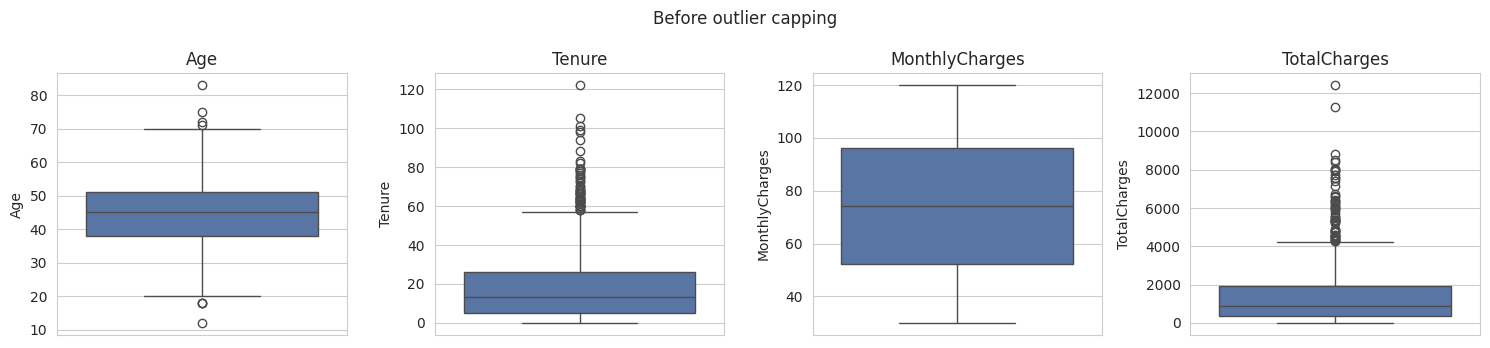

Age: 8 outlier(s) outside [18.5, 70.5]
Tenure: 61 outlier(s) outside [-26.5, 57.5]
MonthlyCharges: 0 outlier(s) outside [-13.3, 161.7]
TotalCharges: 57 outlier(s) outside [-1987.2, 4232.6]


In [8]:
numeric_cols = ["Age", "Tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.suptitle("Before outlier capping")
plt.tight_layout()
plt.show()

for col in numeric_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"{col}: {n_out} outlier(s) outside [{lower:.1f}, {upper:.1f}]")

Unlike the missing-value case, these outliers are just statistically extreme (very long tenure, very high total charges) — not errors — so capping them keeps the customers in the data while limiting their leverage on the model.

## 4. Encoding / Feature Preparation

In [9]:
model_df = df.drop(columns=["CustomerID"]).copy()
model_df["Churn"] = model_df["Churn"].map({"Yes": 1, "No": 0})

X = pd.get_dummies(model_df.drop(columns=["Churn"]), drop_first=True)
y = model_df["Churn"]
print("Feature matrix shape:", X.shape)
X.columns.tolist()

Feature matrix shape: (1000, 10)


['Age',
 'Tenure',
 'MonthlyCharges',
 'TotalCharges',
 'Gender_Male',
 'ContractType_One-Year',
 'ContractType_Two-Year',
 'InternetService_Fiber Optic',
 'InternetService_No Internet',
 'TechSupport_Yes']

## 5. Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (800, 10)  Test: (200, 10)


## 6. Classification Model

A Logistic Regression baseline — simple, fast, and its coefficients double as a business explanation later. Features are scaled first since Logistic Regression is sensitive to feature scale.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)
print("Model trained.")

Model trained.


## 7. Evaluation

Accuracy alone would be misleading here given the 88/12 class split, so Precision, Recall and the Confusion Matrix are reported alongside it.

In [12]:
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.965
Precision: 0.962
Recall:    1.000
F1-score:  0.981


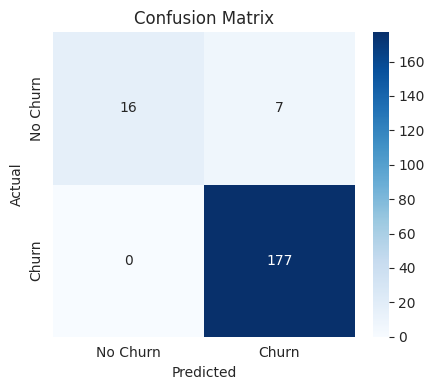

              precision    recall  f1-score   support

    No Churn       1.00      0.70      0.82        23
       Churn       0.96      1.00      0.98       177

    accuracy                           0.96       200
   macro avg       0.98      0.85      0.90       200
weighted avg       0.97      0.96      0.96       200



In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

**Reading the result — and being skeptical of it.** The model catches 100% of churners in the test set (recall) with 96% precision, for 96.5% overall accuracy. That's an unusually clean result for a churn model — real-world churn is noisy, and rarely this separable. It suggests the relationship between these features (especially `TechSupport` and `ContractType`) and `Churn` in this particular dataset is close to a deterministic rule rather than the messier signal you'd see in real customer behavior. The one weak spot: recall on the minority **No Churn** class is only 70% — 7 loyal customers were incorrectly flagged as churn risks.

## 8. Business Interpretation

Logistic Regression coefficients show which factors push churn risk up or down (after scaling, so they're comparable to each other).

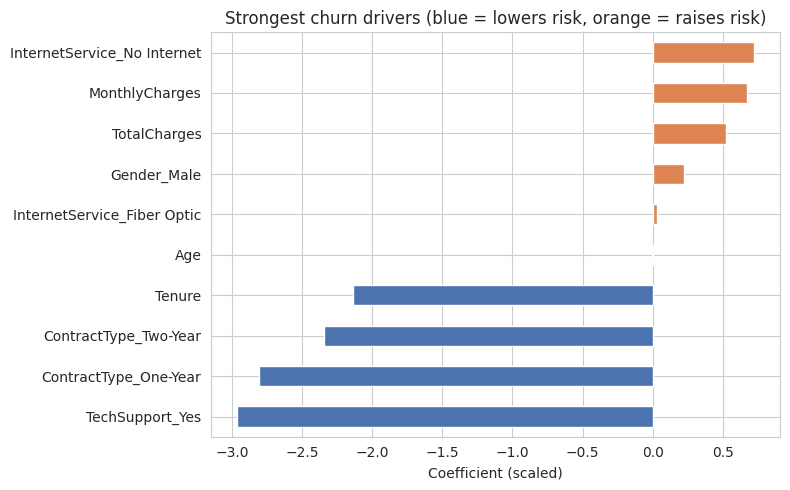

In [14]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
top_bottom = pd.concat([coefs.head(5), coefs.tail(5)])
colors = ["#4C72B0" if v < 0 else "#DD8452" for v in top_bottom.values]
top_bottom.plot(kind="barh", color=colors, ax=ax)
ax.set_title("Strongest churn drivers (blue = lowers risk, orange = raises risk)")
ax.set_xlabel("Coefficient (scaled)")
plt.tight_layout()
plt.show()

**What this means for the business:**
- ⬇️ **Having Tech Support** is by far the strongest protection against churn, followed by a **one/two-year contract** and **longer tenure**.
- ⬆️ **No internet service** and **higher monthly/total charges** are the biggest churn risks.
- Practical read: this points at two clear retention levers — push month-to-month customers toward annual contracts, and make sure Tech Support is easy to get (or bundled in) for at-risk accounts.

## Conclusion

A Logistic Regression baseline on this cleaned dataset reaches 96.5% accuracy, 96% precision and 100% recall on identifying churners — driven mainly by `TechSupport`, `ContractType`, and `Tenure`. Two things worth flagging for anyone building on this: (1) the 88% churn rate here is atypical for real telecom data, and (2) the near-perfect separability suggests this dataset may follow a fairly direct generation rule rather than noisy real-world behavior — so treat this as a solid demonstration of the pipeline, not a production-ready churn benchmark. Next step for a production version: validate the same pipeline against a second, independently-collected dataset before trusting the coefficients.
